In [3]:
# Purpose: Import the PySpark DataFrame, ML, evaluation, plotting, and utility components used in this stage.
from pyspark.sql import functions as F
from pyspark.sql.types import (ArrayType, MapType, StructType)
from pyspark.storagelevel import StorageLevel
from pyspark.ml import Pipeline
import pandas as pd
import matplotlib.pyplot as plt
SEED = 42

In [4]:
# Purpose: Define the GCS input, output, vector, and model locations used by this stage.
NORMALIZED_SPARK_ROOT = ("gs://federal-contracts/staging/" "federal_contracts_uuid_normalized/v1/")
SILVER_ROOT = ("gs://federal-contracts/silver/" "contracts_ml/v1")


In [5]:
# Purpose: Configure Spark shuffle partitioning for the distributed Big Data workload.
# config the  number of partitions (shuffle operation partitions)
spark.conf.set("spark.sql.shuffle.partitions", "192")

## Read the FULL normalized dataset

In [6]:
# Purpose: Load the required Parquet data into `contracts_df` for this Big Data processing stage.
contracts_df = (spark.read.parquet(NORMALIZED_SPARK_ROOT))

In [7]:
# Purpose: Check the dataset width and basic row/column dimensions.
print("Total rows:",f"{contracts_df.count():,}")
print("Columns:",len(contracts_df.columns))

Total rows: 26,837,988
Columns: 58


## PART A — FULL-DATA EDA

In [10]:
# Purpose: Prepare `cols` for the next Big Data processing, analysis, or modeling step.
cols=full_selected.schema.fields
for i in cols:
    col_name=i.name
    print(col_name)

id
award_id
piid
parent_award_piid
award_type
extent_competed
solicitation_procedures
type_of_set_aside
awarding_agency_code
awarding_agency_name
awarding_subagency_code
naics_code
psc_code
recipient_state
pop_state
pop_country
business_types
small_business_flag
woman_owned_flag
veteran_owned_flag
minority_owned_flag
base_and_all_options_value
total_obligation
federal_action_obligation
number_of_offers_received
action_date
period_of_performance_start
period_of_performance_end
fiscal_year
source_year


In [12]:
# Purpose: Define `null_report_fast` to calculate column-level null and empty-value statistics efficiently.
def null_report_fast(df):
    expressions = [F.count("*").alias("__total_rows")]
    for field in df.schema.fields:
        c = field.name
        condition = (F.col(c).isNull())
        #EMPTY STRING AND NULL VALUES 
        if (field.dataType.simpleString()== "string"):
            condition = (condition|(F.trim(F.col(c)) == ""))
        expressions.append(F.sum(F.when(condition,1).otherwise(0)).alias(c))
    result = (df.agg(*expressions).first())
    total = result["__total_rows"]
    rows = []
    for c in df.columns:
        missing = int(result[c] or 0)
        rows.append((c,missing,round(missing/ total* 100,2)))
    return spark.createDataFrame(rows,["column","missing_count","missing_percent"])

In [13]:
# Purpose: Configure Spark Parquet date rebasing for compatibility with legacy date values.
spark.conf.set("spark.sql.parquet.datetimeRebaseModeInRead","LEGACY")
contracts_df = (spark.read.parquet(NORMALIZED_SPARK_ROOT))

In [14]:
# Purpose: Display the resulting Spark rows or summary table for validation and interpretation.
null_before = (null_report_fast(full_selected).orderBy(F.desc("missing_percent"))
)
null_before.show(
    50,
    truncate=False
)

26/08/20 16:00:11 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
26/08/20 16:00:12 WARN DataSourceScanExecUtil: Failed while estimating variable length type: ColumnPath [business_types] not found in the file's metadata.


+---------------------------+-------------+---------------+
|column                     |missing_count|missing_percent|
+---------------------------+-------------+---------------+
|business_types             |26837988     |100.0          |
|woman_owned_flag           |26011516     |96.92          |
|veteran_owned_flag         |26011516     |96.92          |
|minority_owned_flag        |26011516     |96.92          |
|type_of_set_aside          |20434813     |76.14          |
|number_of_offers_received  |17846547     |66.5           |
|small_business_flag        |13258621     |49.4           |
|parent_award_piid          |5300316      |19.75          |
|award_type                 |4907733      |18.29          |
|pop_state                  |1829919      |6.82           |
|pop_country                |1016146      |3.79           |
|period_of_performance_end  |1015607      |3.78           |
|recipient_state            |587955       |2.19           |
|total_obligation           |492306     

## Processing the data cols

In [15]:
# Purpose: Display the resulting Spark rows or summary table for validation and interpretation.
#COUNTING THE NOT NULL COLS IN ALL DATE COLS
date_cols = ["action_date","period_of_performance_start","period_of_performance_end"]
contracts_df.select([F.count(F.col(c)).alias(f"{c}_count")for c in date_cols]).show(truncate=False)

+-----------------+---------------------------------+-------------------------------+
|action_date_count|period_of_performance_start_count|period_of_performance_end_count|
+-----------------+---------------------------------+-------------------------------+
|26837988         |26837593                         |25822381                       |
+-----------------+---------------------------------+-------------------------------+



In [ ]:
# Purpose: Summarize the valid range and coverage of each date field.
date_summary_expressions = [
    expression
    for column_name in date_cols
    for expression in (
        F.min(column_name).alias(f"{column_name}_min"),
        F.max(column_name).alias(f"{column_name}_max"),
        F.count(column_name).alias(f"{column_name}_total"),
        F.countDistinct(column_name).alias(f"{column_name}_distinct"),
    )
]

contracts_df.select(*date_summary_expressions).show(truncate=False)


In [17]:
# Purpose: Display the resulting Spark rows or summary table for validation and interpretation.
rows = []
for c in date_cols:
    stats = contracts_df.select(F.min(c).alias("min_date"), F.max(c).alias("max_date"),
        F.count(c).alias("total_values"), F.countDistinct(c).alias("distinct_dates")).first()
    rows.append((c,stats["min_date"],stats["max_date"],stats["total_values"],stats["distinct_dates"]))
date_summary = spark.createDataFrame(rows,["date_column","min_date","max_date","total_values","distinct_dates"])
date_summary.show(truncate=False)

+---------------------------+----------+----------+------------+--------------+
|date_column                |min_date  |max_date  |total_values|distinct_dates|
+---------------------------+----------+----------+------------+--------------+
|action_date                |2009-10-01|2024-09-30|26837988    |5056          |
|period_of_performance_start|1009-01-26|9019-07-29|26837593    |8771          |
|period_of_performance_end  |1011-09-29|9011-04-30|25822381    |10070         |
+---------------------------+----------+----------+------------+--------------+



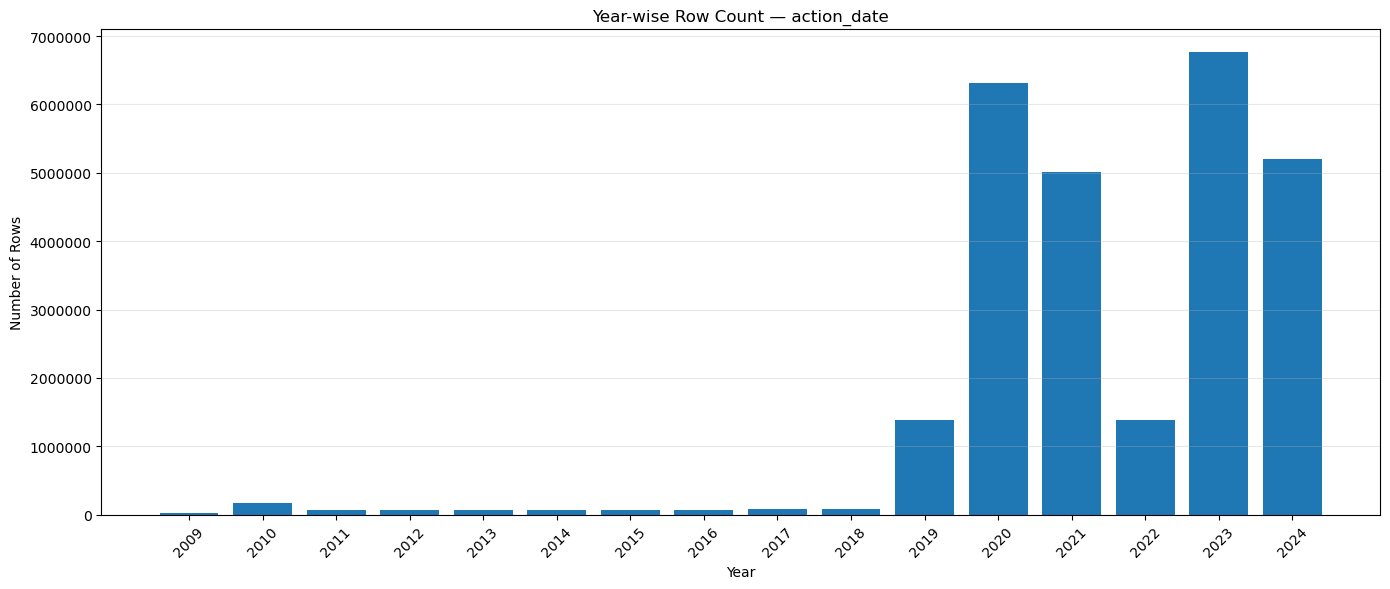

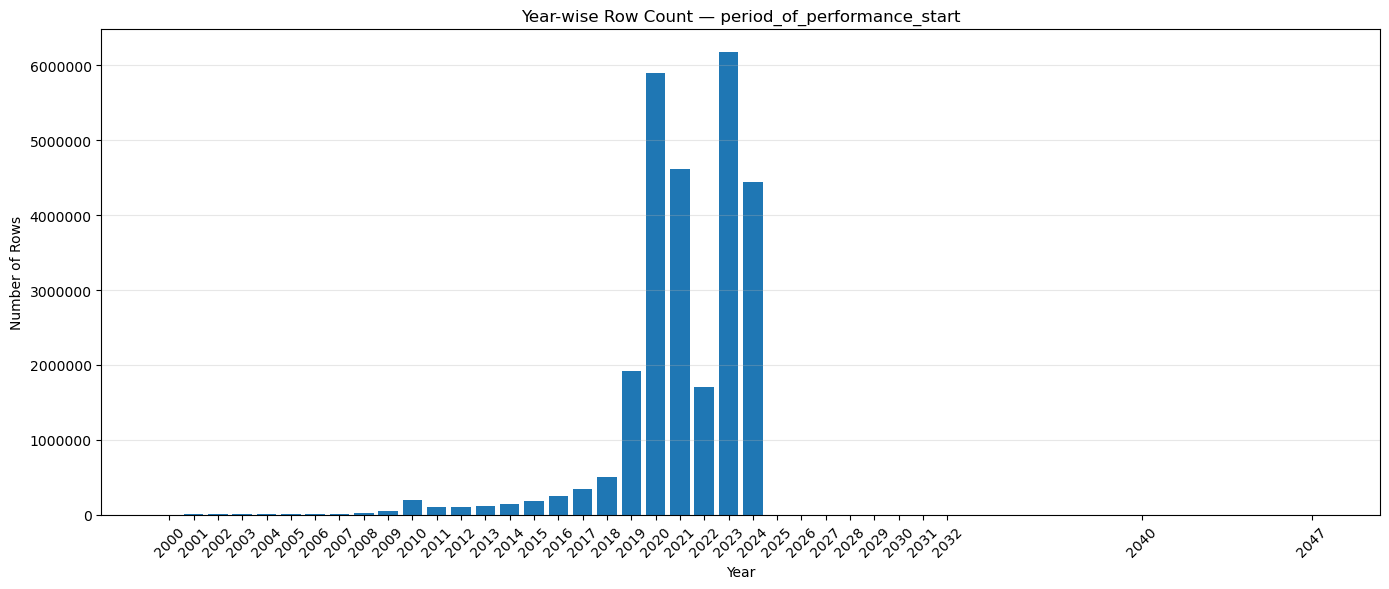

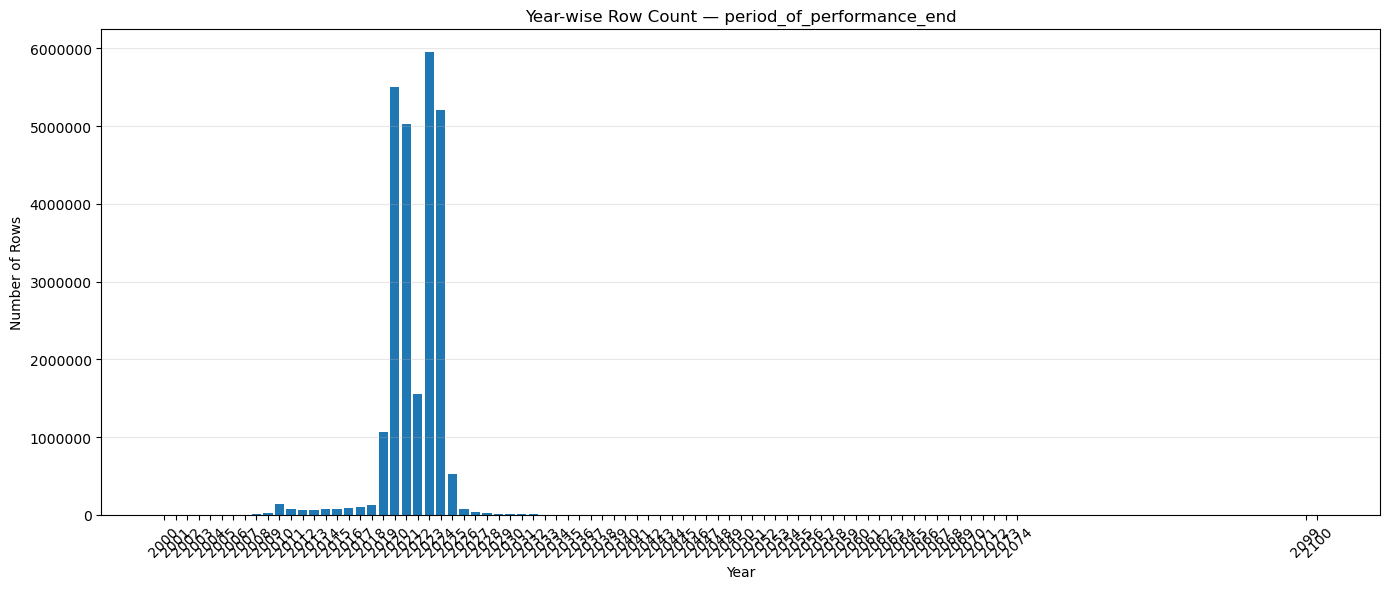

In [18]:
# Purpose: Apply the required Spark column transformation for cleaning or feature engineering.
for c in date_cols:
    year_counts = (contracts_df.filter(F.col(c).isNotNull()).withColumn("year",F.year(F.col(c)))
        .filter((F.col("year") >= 2000) &(F.col("year") <= 2100)).groupBy("year").count().orderBy("year"))
    pdf = year_counts.toPandas()
    plt.figure(figsize=(14, 6))
    plt.bar(pdf["year"],pdf["count"])
    plt.title(f"Year-wise Row Count — {c}")
    plt.xlabel("Year")
    plt.ylabel("Number of Rows")
    plt.xticks(pdf["year"],rotation=45)
    plt.ticklabel_format(style="plain",axis="y")
    plt.grid(axis="y",alpha=0.3)
    plt.tight_layout()
    plt.show()

In [19]:
# Purpose: Filter the Spark records to the valid subset required for the next analysis or modeling step.
contracts_clean_df = (contracts_df.filter((F.col("period_of_performance_start").isNull() | (
                F.col("period_of_performance_start") >= F.lit("2006-01-01").cast("date")
            ) |( F.col("period_of_performance_start") <= F.lit("2098-12-31").cast("date"))) & (
            F.col("period_of_performance_end").isNull()
            | (
                F.col("period_of_performance_end")
                <= F.lit("2098-12-31").cast("date")
            ) |( F.col("period_of_performance_end")
                >= F.lit("1800-01-01").cast("date"))
        )
    )
)

In [20]:
# Purpose: Materialize the Spark DataFrame and verify the number of available records.
invalid_date_rows = (contracts_df.filter(
        (F.col("period_of_performance_start").isNotNull()& (F.year("period_of_performance_start") < 2006) ) |
        (F.col("period_of_performance_end").isNotNull()& (F.year("period_of_performance_end") > 2060))))
print("Rows to remove:",invalid_date_rows.count())

Rows to remove: 43748


In [21]:
# Purpose: Aggregate the Spark data to produce summary statistics for this analysis.
for c in date_cols:
    print(f"\n===== {c} =====")
    contracts_clean_df.groupBy(F.year(F.col(c)).alias("year")).count().orderBy("year").show(200, truncate=False)


===== action_date =====


+----+-------+
|year|count  |
+----+-------+
|2009|31695  |
|2010|167877 |
|2011|75319  |
|2012|68369  |
|2013|63738  |
|2014|73086  |
|2015|68168  |
|2016|72642  |
|2017|80730  |
|2018|76423  |
|2019|1384255|
|2020|6319015|
|2021|5011164|
|2022|1385077|
|2023|6761163|
|2024|5199267|
+----+-------+


===== period_of_performance_start =====


+----+-------+
|year|count  |
+----+-------+
|NULL|395    |
|1009|1      |
|1020|1      |
|1949|2      |
|1950|3      |
|1951|2      |
|1952|2      |
|1953|5      |
|1957|2      |
|1960|2      |
|1962|27     |
|1966|6      |
|1967|5      |
|1968|4      |
|1977|11     |
|1979|56     |
|1980|13     |
|1981|177    |
|1982|1      |
|1984|2      |
|1985|10     |
|1986|6      |
|1987|61     |
|1988|40     |
|1989|3      |
|1990|6      |
|1991|22     |
|1992|14     |
|1993|328    |
|1994|13     |
|1995|27     |
|1996|71     |
|1997|185    |
|1998|282    |
|1999|198    |
|2000|1788   |
|2001|3758   |
|2002|5547   |
|2003|7711   |
|2004|9604   |
|2005|11664  |
|2006|12558  |
|2007|14882  |
|2008|16665  |
|2009|50563  |
|2010|190685 |
|2011|105243 |
|2012|100389 |
|2013|111873 |
|2014|138206 |
|2015|183386 |
|2016|246394 |
|2017|349488 |
|2018|505681 |
|2019|1923898|
|2020|5897744|
|2021|4621778|
|2022|1705472|
|2023|6171856|
|2024|4447026|
|2025|1472   |
|2026|246    |
|2027|285    |
|2028|77  

+----+-------+
|year|count  |
+----+-------+
|NULL|1015607|
|1011|1      |
|1020|2      |
|1995|1      |
|1996|1      |
|1997|9      |
|1998|3      |
|1999|8      |
|2000|13     |
|2001|36     |
|2002|31     |
|2003|114    |
|2004|250    |
|2005|610    |
|2006|1286   |
|2007|2172   |
|2008|3437   |
|2009|18825  |
|2010|133325 |
|2011|77827  |
|2012|62261  |
|2013|62699  |
|2014|72233  |
|2015|79248  |
|2016|88550  |
|2017|103442 |
|2018|121687 |
|2019|1066718|
|2020|5508440|
|2021|5022391|
|2022|1546929|
|2023|5948234|
|2024|5206740|
|2025|529484 |
|2026|76063  |
|2027|32596  |
|2028|21418  |
|2029|12238  |
|2030|3585   |
|2031|6092   |
|2032|5444   |
|2033|667    |
|2034|531    |
|2035|172    |
|2036|259    |
|2037|283    |
|2038|195    |
|2039|454    |
|2040|147    |
|2041|252    |
|2042|96     |
|2043|225    |
|2044|136    |
|2045|175    |
|2046|100    |
|2047|18     |
|2048|122    |
|2049|104    |
|2050|49     |
|2051|69     |
|2052|101    |
|2053|175    |
|2054|211    |
|2055|166 

In [22]:
# Purpose: Filter the Spark records to the valid subset required for the next analysis or modeling step.
## removing the rows where dates are invalid and null dates
contracts_clean_df = contracts_df.filter(
    F.col("period_of_performance_start").isNull()|((F.year("period_of_performance_start") > 2006)&(F.year("period_of_performance_start") < 2040))
    &
    (F.col("period_of_performance_end").isNull()|((F.year("period_of_performance_end") > 1900)&(F.year("period_of_performance_end") < 2100))
    ))

In [23]:
# Purpose: Aggregate the Spark data to produce summary statistics for this analysis.
for c in date_cols:
    print(f"\n===== {c} =====")
    contracts_clean_df.groupBy(F.year(F.col(c)).alias("year")).count().orderBy("year").show(200, truncate=False)



===== action_date =====


+----+-------+
|year|count  |
+----+-------+
|2009|31688  |
|2010|167857 |
|2011|75313  |
|2012|68367  |
|2013|63733  |
|2014|73080  |
|2015|68165  |
|2016|72640  |
|2017|80728  |
|2018|76422  |
|2019|1381001|
|2020|6297347|
|2021|5000361|
|2022|1383308|
|2023|6751368|
|2024|5192296|
+----+-------+


===== period_of_performance_start =====


+----+-------+
|year|count  |
+----+-------+
|NULL|395    |
|2007|14882  |
|2008|16663  |
|2009|50563  |
|2010|190680 |
|2011|105243 |
|2012|100388 |
|2013|111851 |
|2014|138188 |
|2015|183385 |
|2016|246388 |
|2017|349487 |
|2018|505671 |
|2019|1923887|
|2020|5897742|
|2021|4621778|
|2022|1705471|
|2023|6171856|
|2024|4447026|
|2025|1472   |
|2026|246    |
|2027|285    |
|2028|77     |
|2029|28     |
|2030|6      |
|2031|1      |
|2032|15     |
+----+-------+


===== period_of_performance_end =====


+----+-------+
|year|count  |
+----+-------+
|NULL|971490 |
|1996|1      |
|1997|1      |
|1998|1      |
|1999|4      |
|2000|2      |
|2001|15     |
|2002|7      |
|2003|18     |
|2004|39     |
|2005|268    |
|2006|727    |
|2007|1613   |
|2008|3109   |
|2009|18518  |
|2010|133010 |
|2011|77547  |
|2012|61956  |
|2013|62570  |
|2014|72161  |
|2015|79183  |
|2016|88469  |
|2017|103338 |
|2018|121638 |
|2019|1066581|
|2020|5507763|
|2021|5021653|
|2022|1546309|
|2023|5947642|
|2024|5205560|
|2025|528901 |
|2026|75803  |
|2027|32303  |
|2028|21373  |
|2029|12176  |
|2030|3547   |
|2031|6078   |
|2032|5444   |
|2033|579    |
|2034|528    |
|2035|170    |
|2036|259    |
|2037|283    |
|2038|195    |
|2039|407    |
|2040|147    |
|2041|230    |
|2042|96     |
|2043|225    |
|2044|136    |
|2045|160    |
|2046|55     |
|2047|18     |
|2048|122    |
|2049|80     |
|2050|39     |
|2052|31     |
|2053|85     |
|2054|15     |
|2055|127    |
|2056|2      |
|2057|98     |
|2058|477    |
|2059|136 

In [24]:
# Purpose: Check the dataset width and basic row/column dimensions.
len(contracts_clean_df.columns)

58

In [25]:
# Purpose: Aggregate the Spark data to produce summary statistics for this analysis.
contracts_clean_df.groupby().count().show()

+--------+
|   count|
+--------+
|26783674|
+--------+



In [51]:
# Purpose: Define the GCS input, output, vector, and model locations used by this stage.
SILVER_PATH = "gs://federal-contracts/silver/federal_contracts_cleaned/v1/"
(contracts_clean_df.write.mode("overwrite").parquet(SILVER_PATH))
print("Cleaned data saved to:")
print(SILVER_PATH)

26/08/18 13:05:13 WARN DataSourceScanExecUtil: Failed while estimating variable length type: ColumnPath [business_types] not found in the file's metadata.


Cleaned data saved to:
gs://federal-contracts/silver/federal_contracts_cleaned/v1/
